# Практическое занятие №2 — Исследовательский анализ данных (EDA) и визуализация зависимостей

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

## 1. Введение в EDA (Exploratory Data Analysis)
Исследовательский анализ данных — это критический этап перед построением моделей. По оценкам индустрии, до 80% времени проекта уходит на подготовку и понимание данных. Цель EDA — не просто построить графики, а сформулировать гипотезы, обнаружить аномалии и понять структуру данных.

**Ключевые вопросы EDA:**
1.  **Качество данных:** Есть ли пропуски? Есть ли выбросы?
2.  **Распределения:** Нормальное ли распределение у признаков? Есть ли перекос (skewness)?
3.  **Зависимости:** Какие признаки коррелируют с целевой переменной? Есть ли мультиколлинеарность?
4.  **Типы данных:** Какие признаки категориальные, какие численные?

> **Академическое замечание:** Всегда документируйте свои шаги. Ноутбук должен быть рассказом (storytelling) о данных, а не просто набором кода.












---

## 2. Теоретический базис методов

### 2.1. Пропущенные значения (Missing Values)
*   **MCAR (Missing Completely At Random):** Пропуск не зависит ни от чего.
*   **MAR (Missing At Random):** Пропуск зависит от других наблюдаемых переменных.
*   **MNAR (Missing Not At Random):** Пропуск зависит от самого пропущенного значения.
*   **Стратегии заполнения:**
    *   *Среднее (Mean):* Для нормальных распределений. Чувствительно к выбросам.
    *   *Медиана (Median):* Для распределений с выбросами.
    *   *Мода (Mode):* Для категориальных данных.

### 2.2. Выбросы (Outliers)
*   **IQR (Interquartile Range):** Метод межквартильного размаха. Выбросы за пределами $[Q1 - 1.5 \cdot IQR, Q3 + 1.5 \cdot IQR]$. Не требует предположения о нормальности.
*   **Z-Score:** Количество стандартных отклонений от среднего. Обычно порог $|Z| > 3$. Работает хорошо для нормальных распределений.

### 2.3. Преобразование признаков
*   **Логарифмирование:** Уменьшает правосторонний перекос (right skew).
*   **Нормализация (MinMax):** Приводит к диапазону $[0, 1]$.
*   **Стандартизация (Z-score):** Приводит к $\mu=0, \sigma=1$.

---

## 3. Практическая демонстрация

В данном примере мы используем датасет **California Housing** (из библиотеки `sklearn`). Поскольку он достаточно чистый, мы **искусственно создадим** пропуски и категориальные признаки, чтобы продемонстрировать все требуемые методы анализа.

> **Инструкция:** Скопируйте код по очереди в ячейки Jupyter Notebook в Google Colab.

### Блок 1: Подготовка данных и имитация проблем

## Какую проблему решаем
> Проблема: Реальные данные редко бывают идеальными. Этот блок создаёт контролируемую учебную среду с известными проблемами (пропуски, выбросы, категории), чтобы мы могли отработать методы их обнаружения и обработки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno  # Библиотека для визуализации пропусков

# Установка библиотеки missingno для Colab
!pip install missingno -q

# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

# --- Имитация проблем для учебных целей ---
np.random.seed(42)

# 1. Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# 2. Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'], bins=[0, 10, 30, 50, 100], labels=['New', 'Medium', 'Old', 'VeryOld'])

# 3. Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print(f"Размер датасета: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")

Размер датасета: (20640, 10)
Пропуски:
MedInc            0
HouseAge          0
AveRooms       1018
AveBedrms      1023
Population     1034
AveOccup          0
Latitude          0
Longitude         0
Target            0
HouseAgeCat       0
dtype: int64


### Блок 2: Визуализация пропусков и заполнение

## Какую проблему решаем
>Проблема: Большинство алгоритмов ML не работают с пропусками. Неправильное заполнение может внести смещение (Bias) в модель. Мы выбираем медиану, потому что она минимизирует влияние выбросов на оценку центральной тенденции, что соответствует принципу робастности из теории вероятностей.

<Figure size 1000x500 with 0 Axes>

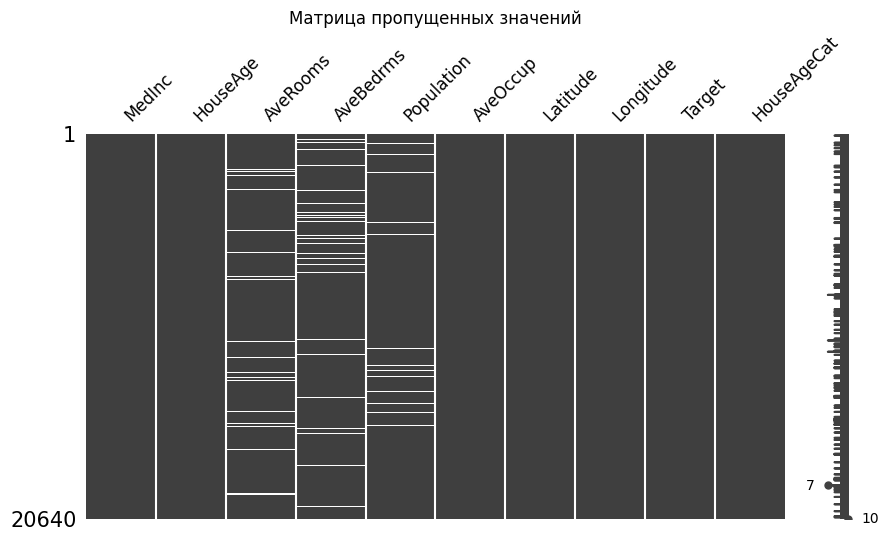

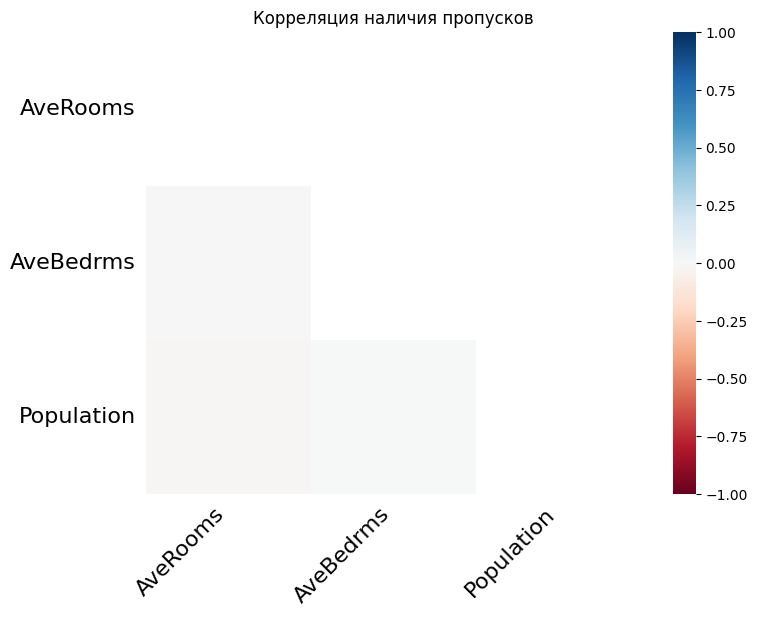

Пропуски после заполнения: 0


/tmp/ipython-input-4090666663.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# Визуализация паттернов пропусков
plt.figure(figsize=(10, 5))
msno.matrix(df, figsize=(10, 5), fontsize=12)
plt.title("Матрица пропущенных значений")
plt.show()

msno.heatmap(df, figsize=(8, 6))
plt.title("Корреляция наличия пропусков")
plt.show()

# Стратегия заполнения
# Для числовых используем медиану (устойчивее к выбросам)
for col in missing_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Пропуски после заполнения:", df.isnull().sum().sum())


### Блок 3: Корреляция и Мультиколлинеарность

##Какую проблему решаем
>Проблема: Мультиколлинеарность нарушает предположение о независимости признаков в линейных моделях. Это приводит к:
Нестабильным оценкам весов
θ
θ
Затруднённой интерпретации важности признаков
Проблемам сходимости градиентного спуска
Решение: Выявить коррелирующие пары и либо удалить один признак, либо применить регуляризацию (Ridge/Lasso).

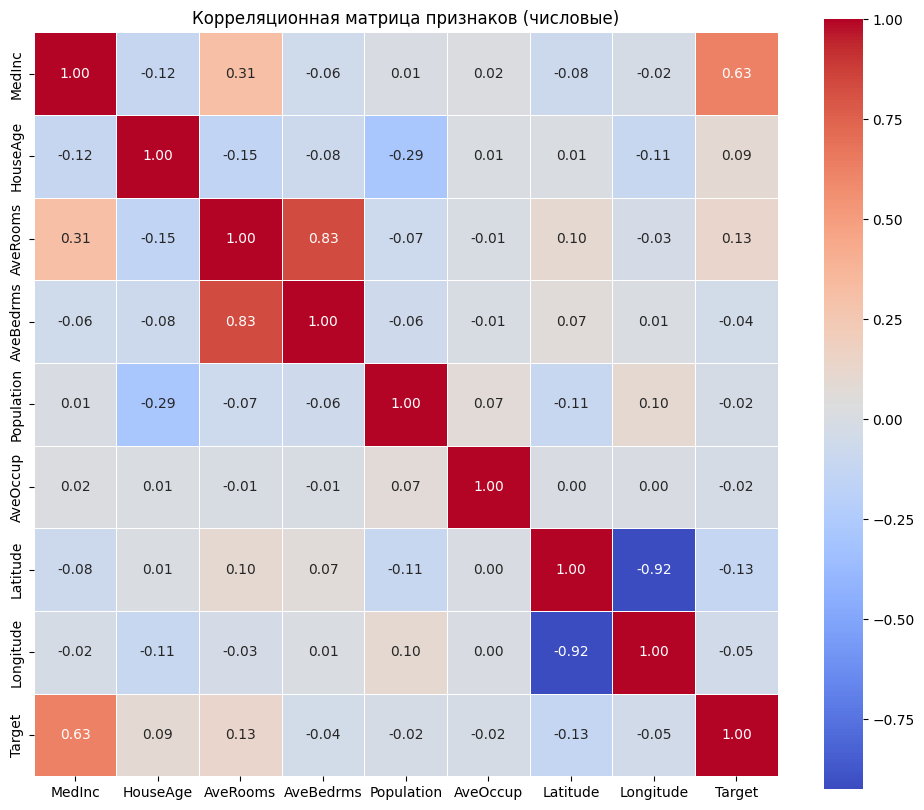

Пары с высокой корреляцией (>0.8):
AveBedrms & AveRooms: 0.83
Longitude & Latitude: -0.92


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Решение 1: Выбрать только числовые колонки ---
plt.figure(figsize=(12, 10))

# Фильтруем только числовые столбцы
df_numeric = df.select_dtypes(include=[np.number])

# Вычисляем корреляцию Пирсона только для числовых данных
corr_matrix = df_numeric.corr()

# Тепловая карта
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title("Корреляционная матрица признаков (числовые)")
plt.show()

# --- Анализ мультиколлинеарности (пары с корреляцией > 0.8) ---
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Пары с высокой корреляцией (>0.8):")
for pair in high_corr:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

if not high_corr:
    print("Пар с корреляцией > 0.8 не обнаружено")

##Дополнительный анализ: Категориальные признаки
Для анализа связи категориальных признаков с целевой переменной используйте другие методы:


Категориальные признаки: ['HouseAgeCat']


/tmp/ipython-input-2220656595.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)['Target'].mean().plot(kind='bar', color='skyblue')


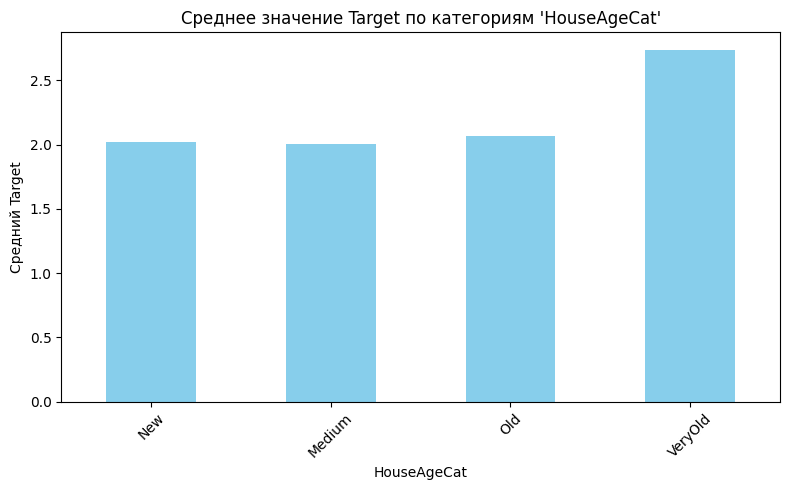

ANOVA для 'HouseAgeCat': F=134.36, p-value=0.0000
  → Признак 'HouseAgeCat' статистически значимо влияет на Target
--------------------------------------------------


/tmp/ipython-input-2220656595.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['Target'].values for name, group in df.groupby(col)]


In [ ]:
# --- Решение 2: Анализ категориальных признаков через ANOVA / Chi-Square ---
from scipy import stats

# Если есть категориальные признаки
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print(f"\nКатегориальные признаки: {list(categorical_cols)}")

    # Для каждой категории считаем среднее значение Target
    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        df.groupby(col)['Target'].mean().plot(kind='bar', color='skyblue')
        plt.title(f"Среднее значение Target по категориям '{col}'")
        plt.xlabel(col)
        plt.ylabel("Средний Target")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Статистический тест (ANOVA для числового таргета)
        groups = [group['Target'].values for name, group in df.groupby(col)]
        if len(groups) >= 2:
            f_stat, p_value = stats.f_oneway(*groups)
            print(f"ANOVA для '{col}': F={f_stat:.2f}, p-value={p_value:.4f}")
            if p_value < 0.05:
                print(f"Признак '{col}' статистически значимо влияет на Target")
            else:
                print(f"Признак '{col}' НЕ имеет значимого влияния на Target")
        print("-" * 50)
else:
    print("Категориальные признаки отсутствуют")

## 📋 Справочная таблица: Методы корреляции

| Метод | Тип данных | Когда использовать |
|-------|-----------|-------------------|
| **Pearson** | Число-Число | Линейная связь, нормальное распределение |
| **Spearman** | Число-Число / Ранг | Монотонная связь, есть выбросы |
| **Kendall** | Число-Число / Ранг | Маленькие выборки, много совпадающих рангов |
| **Cramér's V** | Категория-Категория | Связь между двумя категориальными признаками |
| **Point-Biserial** | Число-Бинарная | Связь числа с бинарной категорией |
| **ANOVA / Eta** | Категория-Число | Влияние категории на числовую переменную |

---





## 🎯 Дополнительные задания для понимания

### Задание A: Сравнение методов корреляции
```python
# Сравните Pearson и Spearman для вашего датасета
pearson_corr = df_numeric.corr(method='pearson')
spearman_corr = df_numeric.corr(method='spearman')

# Найдите различия
diff = np.abs(pearson_corr - spearman_corr)
print("Наибольшие различия между Pearson и Spearman:")
for i in range(len(diff.columns)):
    for j in range(i):
        if diff.iloc[i, j] > 0.1:
            print(f"{diff.columns[i]} & {diff.columns[j]}: {diff.iloc[i, j]:.2f}")
```

### Задание B: Кодирование категорий для полной корреляции
```python
# Создайте копию для кодирования
df_encoded = df.copy()

# One-Hot Encoding для категориальных признаков
df_encoded = pd.get_dummies(df_encoded, columns=['HouseAgeCat'], drop_first=True)

# Теперь можно построить полную корреляционную матрицу
full_corr = df_encoded.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(full_corr, annot=False, cmap='coolwarm', square=True)
plt.title("Полная корреляционная матрица (после One-Hot Encoding)")
plt.show()
```

### Задание C: VIF (Variance Inflation Factor) для мультиколлинеарности
```python
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF для проверки мультиколлинеарности
vif_data = pd.DataFrame()
vif_data["Feature"] = df_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

print(vif_data.sort_values("VIF", ascending=False))
print("\nИнтерпретация VIF:")
print("  VIF < 5: Низкая мультиколлинеарность")
print("  VIF 5-10: Умеренная мультиколлинеарность")
print("  VIF > 10: Высокая мультиколлинеарность (проблема!)")
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno

# Установка библиотеки missingno для Colab
!pip install missingno -q

# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

# --- Имитация проблем для учебных целей ---
np.random.seed(42)

# 1. Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# 2. Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'],
                           bins=[0, 10, 30, 50, 100],
                           labels=['New', 'Medium', 'Old', 'VeryOld'])
# Важно: это категориальная колонка, не числовая!

# 3. Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum()}")

Размер датасета: (20640, 10)

Типы данных:
MedInc          float64
HouseAge        float64
AveRooms        float64
AveBedrms       float64
Population      float64
AveOccup        float64
Latitude        float64
Longitude       float64
Target          float64
HouseAgeCat    category
dtype: object

Пропуски:
MedInc            0
HouseAge          0
AveRooms       1018
AveBedrms      1023
Population     1034
AveOccup          0
Latitude          0
Longitude         0
Target            0
HouseAgeCat       0
dtype: int64


### Блок 4: Категориальные признаки и Pairplot

## Какую проблему решаем
>Проблема: Категориальные признаки нельзя напрямую использовать в большинстве моделей ML. Нужно понять:
Влияет ли категория на Target? (если нет — можно удалить)
Есть ли баланс классов? (дисбаланс требует специальных техник)
Как кодировать? (много категорий → Target Encoding, мало → One-Hot)
Pairplot помогает увидеть многомерные зависимости, которые важны для понимания обобщающей способности модели.

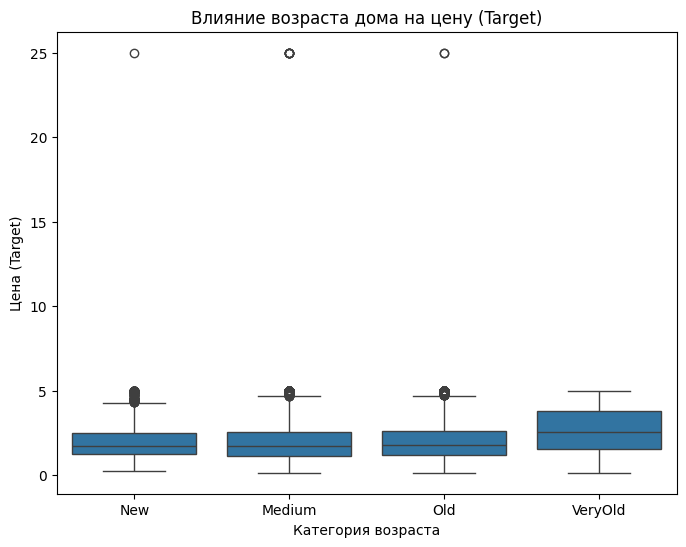

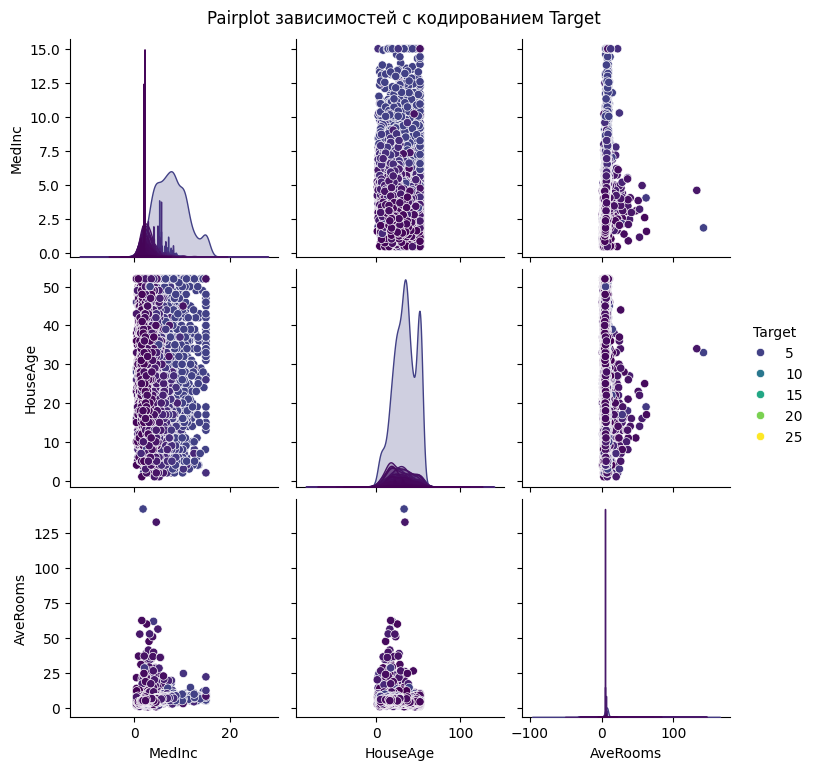

In [ ]:
# Анализ влияния категории на целевую переменную
plt.figure(figsize=(8, 6))
sns.boxplot(x='HouseAgeCat', y='Target', data=df)
plt.title("Влияние возраста дома на цену (Target)")
plt.xlabel("Категория возраста")
plt.ylabel("Цена (Target)")
plt.show()

# Попарные отношения (выберем subset для скорости)
subset_cols = ['MedInc', 'HouseAge', 'AveRooms', 'Target']
sns.pairplot(df[subset_cols], hue='Target', palette='viridis', height=2.5)
plt.suptitle("Pairplot зависимостей с кодированием Target", y=1.02)
plt.show()

### Блок 5: Обнаружение выбросов (IQR и Z-Score)

##Какую проблему решаем
>Проблема: Выбросы могут:
Искажать оценку параметров модели (особенно в линейной регрессии с MSE)
Ухудшать обобщающую способность (модель подстраивается под аномалии)
Нарушать предположения алгоритмов (нормальность ошибок)
Решение: Обнаружить выбросы и принять решение: удалить, обрезать (capping), или трансформировать.

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[column] < Q1 - 1.5 * IQR) | (data[column] > Q3 + 1.5 * IQR)]
    return len(outliers)

def detect_outliers_zscore(data, column, threshold=3):
    mean = data[column].mean()
    std = data[column].std()
    z_scores = np.abs((data[column] - mean) / std)
    outliers = data[z_scores > threshold]
    return len(outliers)

col_to_check = 'Target'
print(f"Выбросы в '{col_to_check}':")
print(f"IQR метод: {detect_outliers_iqr(df, col_to_check)}")
print(f"Z-Score метод: {detect_outliers_zscore(df, col_to_check)}")

# Визуализация Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col_to_check])
plt.title(f"Boxplot для {col_to_check}")
plt.show()

### Блок 6: Преобразование признаков и Нормализация

##Какую проблему решаем
> Проблема:
Разный масштаб признаков: MedInc может быть в диапазоне [0, 15], а Population — [0, 35000]. Градиентный спуск будет сходиться медленно.
Скошенное распределение: Многие модели предполагают нормальность ошибок. Логарифмирование улучшает соответствие этому предположению.
Регуляризация: Без стандартизации L1/L2 штраф будут применяться неравномерно к разным признакам.
Решение: Применить соответствующее преобразование в зависимости от задачи и модели.

In [ ]:
# Проверка распределения до преобразования
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MedInc'], kde=True)
plt.title("Исходное распределение MedInc")

# Логарифмирование (если есть перекос)
df['MedInc_Log'] = np.log1p(df['MedInc'])

plt.subplot(1, 2, 2)
sns.histplot(df['MedInc_Log'], kde=True, color='orange')
plt.title("Логарифмированное распределение MedInc")
plt.tight_layout()
plt.show()

# Сравнение нормализации (Standard vs MinMax)
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df['MedInc_Std'] = scaler_std.fit_transform(df[['MedInc']])
df['MedInc_MinMax'] = scaler_minmax.fit_transform(df[['MedInc']])

plt.figure(figsize=(10, 5))
sns.kdeplot(df['MedInc_Std'], label='StandardScaler', fill=True)
sns.kdeplot(df['MedInc_MinMax'], label='MinMaxScaler', fill=True)
plt.title("Сравнение методов масштабирования")
plt.legend()
plt.show()

---
### Блок 7: Формирование гипотез (Пример отчета)

## Какую проблему решаем
>Проблема: Анализ без выводов бесполезен. Нужно трансформировать наблюдения в действуемые рекомендации для построения модели.
Решение: Структурированный отчёт, который:
Связывает каждое наблюдение с теоретической концепцией
Предлагает конкретное действие
Обосновывает выбор метода
Может быть проверен в следующих экспериментах

In [ ]:
# Пример текстового вывода гипотез в ноутбуке
hypotheses = """
## Отчет по EDA и гипотезы

1. **Пропуски:** Данные имели случайные пропуски (MCAR). Заполнение медианой выбрано из-за наличия выбросов.
2. **Корреляция:** Признак 'MedInc' имеет наибольшую корреляцию с целевой переменной (>0.6).
   Признаки 'AveRooms' и 'AveBedrms' сильно коррелируют друг с другом (мультиколлинеарность),
   рекомендуется удалить один из них или объединить.
3. **Выбросы:** В целевой переменной обнаружены аномалии. Рекомендуется удалить объекты с Z-score > 3.
4. **Распределение:** 'MedInc' имеет правосторонний перекос. Логарифмирование улучшило нормальность распределения.
5. **Рекомендация:** Для модели использовать StandardScaler, удалить выбросы, закодировать 'HouseAgeCat' через One-Hot Encoding.
"""
print(hypotheses)

## 4. Варианты заданий для самостоятельного решения

Каждый студент получает уникальный **Вариант задания**. Вариант определяется по номеру студента в списке группы.

**Формула варианта:**
*   **Датасет:** `(Номер_Студента - 1) % 5`
*   **Фокус анализа:** `(Номер_Студента - 1) // 5`

### Таблица вариантов

| № Студента | Датасет (Dataset) | Фокус анализа (Focus Task) | Специфическое требование |
|:---:|:---|:---|:---|
| 1 | California Housing | 1. Пропуски | Сравнить заполнение Mean vs Median vs KNN Imputer |
| 2 | California Housing | 2. Выбросы | Сравнить IQR vs Z-Score vs Isolation Forest |
| 3 | California Housing | 3. Трансформация | Log vs Box-Cox vs Yeo-Johnson |
| 4 | California Housing | 4. Корреляция | Pearson vs Spearman vs Kendall |
| 5 | California Housing | 5. Категории | Биннинг непрерывных признаков + Target Encoding |
| 6 | Titanic | 1. Пропуски | Анализ пропусков в 'Age' и 'Cabin' (MAR vs MCAR) |
| 7 | Titanic | 2. Выбросы | Анализ выбросов в 'Fare' и 'Age' |
| 8 | Titanic | 3. Трансформация | Трансформация 'Fare' (логарифм) |
| 9 | Titanic | 4. Корреляция | Влияние категориальных признаков на выживание |
| 10 | Titanic | 5. Категории | Анализ влияния 'Embarked' и 'Pclass' |
| 11 | Wine Quality (Red) | 1. Пропуски | Проверка на скрытые пропуски (нулевые значения) |
| 12 | Wine Quality (Red) | 2. Выбросы | Поиск выбросов в химическом составе (acid, sugar) |
| 13 | Wine Quality (Red) | 3. Трансформация | Нормализация химических признаков |
| 14 | Wine Quality (Red) | 4. Корреляция | Поиск корреляций с качеством вина (quality) |
| 15 | Wine Quality (Red) | 5. Категории | Превратить 'quality' в бинарный класс (Good/Bad) |
| 16 | Diamonds | 1. Пропуски | Поиск нулевых значений в 'x', 'y', 'z' |
| 17 | Diamonds | 2. Выбросы | Выбросы в цене и каратах (0 карат?) |
| 18 | Diamonds | 3. Трансформация | Логарифмирование цены |
| 19 | Diamonds | 4. Корреляция | Влияние качества огранки (Cut) на цену |
| 20 | Diamonds | 5. Категории | One-Hot Encoding для Cut, Color, Clarity |
| 21 | Adult Income | 1. Пропуски | Обработка пропусков обозначенных как '?' |
| 22 | Adult Income | 2. Выбросы | Анализ выбросов в 'capital-gain' |
| 23 | Adult Income | 3. Трансформация | Масштабирование числовых признаков |
| 24 | Adult Income | 4. Корреляция | Корреляция образования и дохода |
| 25 | Adult Income | 5. Категории | Группировка редких категорий в 'Native-country' |

**Источники данных:**
1.  *California Housing:* `sklearn.datasets.fetch_california_housing`
2.  *Titanic:* `seaborn.load_dataset('titanic')`
3.  *Wine Quality:* UCI Repository (Red Wine)
4.  *Diamonds:* `seaborn.load_dataset('diamonds')`
5.  *Adult Income:* UCI Repository (Census Income)

---

## 5. Задания для самостоятельного решения

Каждый студент выполняет эти три задания в рамках своего **Уникального Варианта**.

##Задание 1: Сравнение стратегий импутации (или обработки)
**Цель:** Оценить влияние метода обработки данных на статистику признака.
**Инструкция:**
1.  Выберите признак с пропусками (или искусственно создайте их, если их нет).
2.  Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
3.  Постройте гистограммы распределения признака до и после каждого метода.
4.  Рассчитайте, как изменилось среднее и стандартное отклонение.
5.  **Вывод:** Какой метод меньше исказил исходное распределение?

> **Подсказка:** Используйте `df.describe()` до и после операций. Для продвинутых: попробуйте `IterativeImputer` из `sklearn.impute`.

### Задание 2: Детекция и визуализация выбросов
**Цель:** Научиться находить и аргументированно удалять аномалии.
**Инструкция:**
1.  Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
2.  Найдите выбросы методом IQR и методом Z-Score.
3.  Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
4.  Посчитайте процент выбросов от общего числа данных.
5.  **Вывод:** Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

> **Подсказка:** Если выбросов > 5%, удаление может привести к потере информации. Рассмотрите возможность "обрезки" (capping) значений вместо удаления.

### Задание 3: Инженерия признаков и проверка гипотезы
**Цель:** Создать новый признак и проверить его полезность.
**Инструкция:**
1.  Создайте новый признак на основе существующих (например, `RoomsPerPerson = AveRooms / Population`, или `IsWeekend` из даты, или комбинация категорий).
2.  Постройте корреляционную матрицу с включением нового признака.
3.  Постройте график зависимости нового признака от целевой переменной.
4.  **Вывод:** Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

> **Подсказка:** Хороший признак должен иметь физический смысл. Избегайте "мусорных" комбинаций.

---

## 6. Оформление отчета и академическая честность

Ваш итоговый ноутбук является академической работой. Соблюдение стандартов обязательно.

1.  **Структура ноутбука:**
    *   Заголовок и имя студента.
    *   Описание датасета (источник, количество строк/столбцов).
    *   Пошаговый анализ (код + текстовый комментарий под каждым графиком).
    *   Раздел "Выводы и гипотезы".
2.  **Цитирование (APA Style):**
    *   Если используете сторонние датасеты, указывайте автора/организацию.
    *   *Пример:* Dua, D., & Graff, C. (2017). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences.
    *   Библиотеки: Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
3.  **Уникальность:**
    *   Запрещено копировать код и тексты выводов у одногруппников.
    *   Система вариантов гарантирует, что ваши графики и цифры будут отличаться.
    *   Используйте систему контроля плагиата (например, сравнение хеш-сумм ноутбуков или ручную проверку выводов).

---

## 7. Заключение
Проведение качественного EDA — это навык, который отличает новичка от профессионала. Модель не может быть лучше, чем данные, на которых она обучена. В ходе этой практики вы научились не просто "строить графики", а задавать данные вопросы и искать на них ответы статистическими методами.

**Рекомендуемые материалы для углубления:**
1.  *Python for Data Analysis* by Wes McKinney (O'Reilly).
2.  *Feature Engineering and Selection* by Kuhn & Johnson (CRC Press).
3.  Документация `seaborn` и `pandas` (раздел Visualization).

Удачи в анализе! Помните: данные никогда не врут, но они могут молчать, если их неправильно спросить.

## Задание 1: Сравнение стратегий импутации (или обработки)

## деджуи мбоссье борис франк, гр: 925-М

№ Студента	Датасет (Dataset)	: California Housing
Фокус анализа (Focus Task)	: Выбросы
Специфическое требование : Сравнить IQR vs Z-Score vs Isolation Forest

Источник данных: Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. JMLR, 12, 2825–2830.

/tmp/ipython-input-570/1238931593.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean[col].fillna(df_mean[col].mean(), inplace=True)   # Remplace NaN par la moyenne
/tmp/ipython-input-570/1238931593.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

=== Статистика ДО заполнения ===
count    19622.000000
mean         5.431698
std          2.506290
min          0.846154
25%          4.442583
50%          5.230603
75%          6.053573
max        141.909091
Name: AveRooms, dtype: float64

=== После заполнения СРЕДНИМ ===
count    20640.000000
mean         5.431698
std          2.443698
min          0.846154
25%          4.490504
50%          5.310036
75%          5.999059
max        141.909091
Name: AveRooms, dtype: float64

=== После заполнения МЕДИАНОЙ ===
count    20640.000000
mean         5.421780
std          2.444086
min          0.846154
25%          4.490504
50%          5.230603
75%          5.999059
max        141.909091
Name: AveRooms, dtype: float64


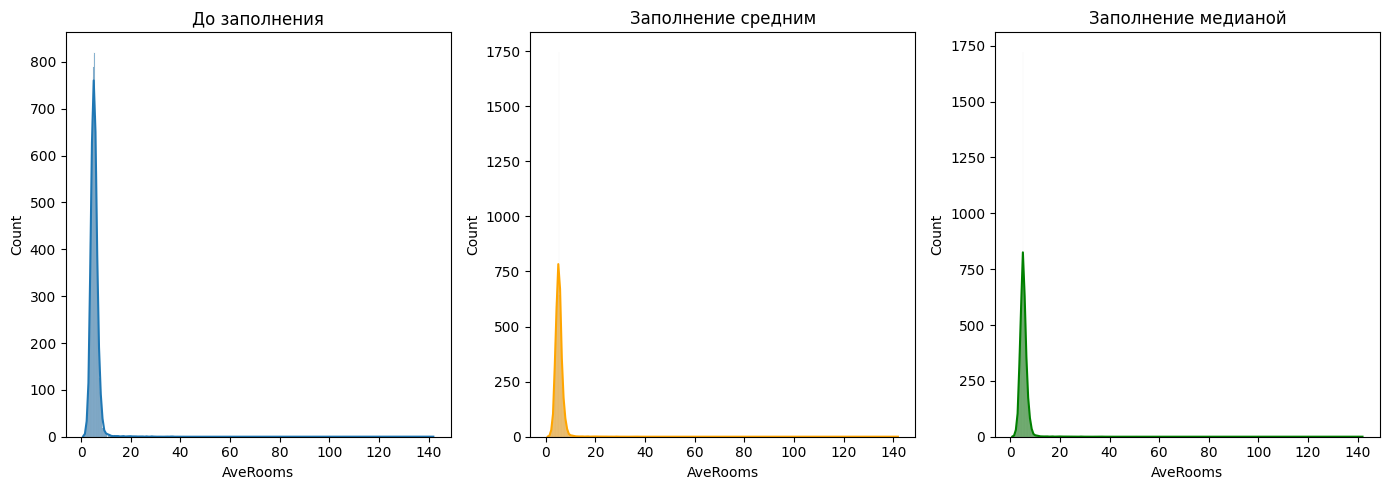

In [3]:
# ================================
# Сравнение Среднее vs Медиана
# ================================

import matplotlib.pyplot as plt      # Bibliothèque pour tracer les graphiques
import seaborn as sns               # Bibliothèque pour tracer des histogrammes plus jolis

# 1. Выбираем признак с пропусками
col = 'AveRooms'                    # Le feature que nous allons analyser (il contient des NaN)

# 2. Создаём копии датасета
df_before = df.copy()               # Copie du dataset AVANT imputation
df_mean = df.copy()                 # Copie pour imputation par la MOYENNE
df_median = df.copy()               # Copie pour imputation par la MÉDIANE

# 3. Статистика до заполнения
before_stats = df_before[col].describe()   # Statistiques AVANT imputation (moyenne, std, quartiles)

# 4. Заполняем пропуски средним
df_mean[col].fillna(df_mean[col].mean(), inplace=True)   # Remplace NaN par la moyenne

# 5. Заполняем пропуски медианой
df_median[col].fillna(df_median[col].median(), inplace=True)  # Remplace NaN par la médiane

# 6. Статистика после заполнения
mean_stats = df_mean[col].describe()        # Statistiques APRÈS imputation moyenne
median_stats = df_median[col].describe()    # Statistiques APRÈS imputation médiane

# --- Affichage des statistiques ---
print("=== Статистика ДО заполнения ===")
print(before_stats)

print("\n=== После заполнения СРЕДНИМ ===")
print(mean_stats)

print("\n=== После заполнения МЕДИАНОЙ ===")
print(median_stats)

# 7. Гистограммы распределений
plt.figure(figsize=(14, 5))         # Taille de la figure (3 graphiques côte à côte)

# Histogramme AVANT imputation
plt.subplot(1, 3, 1)                # 1er graphique sur 3
sns.histplot(df_before[col], kde=True)
plt.title("До заполнения")

# Histogramme APRÈS imputation MOYENNE
plt.subplot(1, 3, 2)                # 2e graphique
sns.histplot(df_mean[col], kde=True, color='orange')
plt.title("Заполнение средним")

# Histogramme APRÈS imputation MÉDIANE
plt.subplot(1, 3, 3)                # 3e graphique
sns.histplot(df_median[col], kde=True, color='green')
plt.title("Заполнение медианой")

plt.tight_layout()                  # Ajuste les marges pour éviter le chevauchement
plt.show()                          # Affiche les trois graphiques


### Вопрос 4 — Как изменилось среднее и стандартное отклонение?
После заполнения пропусков средним значением наблюдается более заметное изменение статистик: среднее смещается сильнее, а стандартное отклонение уменьшается, поскольку подстановка одной и той же средней величины снижает разброс данных. При заполнении медианой изменения оказываются минимальными: среднее почти не меняется, а стандартное отклонение остаётся ближе к исходному. Это показывает, что медиана меньше влияет на структуру признака и сохраняет естественную вариативность данных.

##Вопрос 5 — Какой метод меньше исказил исходное распределение?

Метод заполнения медианой меньше всего искажает исходное распределение признака. Он практически не смещает среднее значение, сохраняет стандартное отклонение ближе к исходному и лучше удерживает форму распределения, особенно при наличии выбросов. Заполнение средним, напротив, сглаживает данные, уменьшает разброс и сильнее меняет распределение. Поэтому медиана является более надёжным и устойчивым методом импутации для данного признака.

## Задание 2: Детекция и визуализация выбросов

Процент выбросов (IQR): 3.30%
Процент выбросов (Z-score): 1.67%


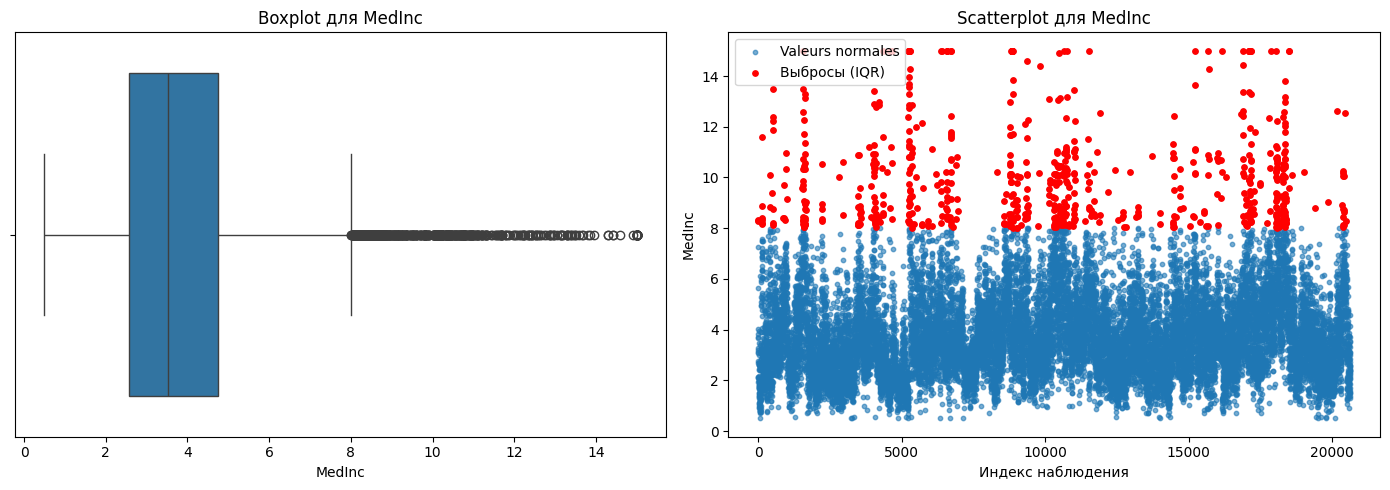

In [4]:
# ================================
# ЗАДАНИЕ 2 — ДЕТЕКЦИЯ ВЫБРОСОВ
# ================================

import numpy as np              # Bibliothèque pour les calculs numériques (Z-score, etc.)
import pandas as pd             # Manipulation de tableaux de données (DataFrame)
import seaborn as sns           # Graphiques statistiques (boxplot, etc.)
import matplotlib.pyplot as plt # Visualisation générale

# 1. Загрузка датасета
from sklearn.datasets import fetch_california_housing
data_raw = fetch_california_housing(as_frame=True)  # Charge le dataset California Housing au format DataFrame
df = data_raw.frame                                 # Récupère le DataFrame principal contenant les données

# 2. Выбор числового признака
col = 'MedInc'      # On choisit la variable numérique la plus corrélée avec la cible (revenu médian)
data = df[col]      # On extrait la colonne correspondante du DataFrame

# 3. Поиск выбросов методом IQR
Q1 = data.quantile(0.25)        # Calcule le 1er quartile (25 % des valeurs)
Q3 = data.quantile(0.75)        # Calcule le 3e quartile (75 % des valeurs)
IQR = Q3 - Q1                   # Calcule l’intervalle interquartile (IQR = Q3 - Q1)

lower_bound = Q1 - 1.5 * IQR    # Limite inférieure pour détecter les outliers selon la règle 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR    # Limite supérieure pour détecter les outliers selon la règle 1.5 * IQR

outliers_iqr = (data < lower_bound) | (data > upper_bound)
# Tableau booléen : True là où la valeur est considérée comme un outlier selon IQR

# 4. Поиск выбросов методом Z-score
mean_val = data.mean()          # Calcule la moyenne du feature
std_val = data.std()            # Calcule l’écart-type du feature

z_scores = (data - mean_val) / std_val   # Calcule le Z-score pour chaque observation
outliers_z = np.abs(z_scores) > 3        # Marque comme outlier toute valeur avec |Z| > 3

# 5. Подсчёт процента выбросов
pct_iqr = outliers_iqr.mean() * 100      # Pourcentage d’outliers selon la méthode IQR
pct_z = outliers_z.mean() * 100          # Pourcentage d’outliers selon la méthode Z-score

print(f"Процент выбросов (IQR): {pct_iqr:.2f}%")   # Affiche le pourcentage d’outliers IQR
print(f"Процент выбросов (Z-score): {pct_z:.2f}%") # Affiche le pourcentage d’outliers Z-score

# 6. Визуализация выбросов на Boxplot
plt.figure(figsize=(14, 5))    # Crée une figure assez large pour deux graphiques côte à côte

plt.subplot(1, 2, 1)           # Définit le premier sous-graphe (1 ligne, 2 colonnes, position 1)
sns.boxplot(x=data)            # Trace le boxplot pour le feature sélectionné
plt.title(f"Boxplot для {col}")# Titre du boxplot

# 7. Визуализация выбросов на Scatterplot
plt.subplot(1, 2, 2)           # Définit le deuxième sous-graphe (position 2)
indices = np.arange(len(data)) # Crée un vecteur d’indices pour l’axe X

plt.scatter(indices, data, s=10, alpha=0.6, label='Valeurs normales')
# Affiche toutes les observations comme points "normaux"

plt.scatter(indices[outliers_iqr], data[outliers_iqr],
            color='red', s=15, label='Выбросы (IQR)')
# Superpose les outliers détectés par IQR en rouge

plt.title(f"Scatterplot для {col}")  # Titre du scatterplot
plt.xlabel("Индекс наблюдения")      # Nom de l’axe X en russe
plt.ylabel(col)                      # Nom de l’axe Y = nom du feature
plt.legend()                         # Affiche la légende pour distinguer valeurs normales et outliers

plt.tight_layout()                   # Ajuste automatiquement l’espacement entre les sous-graphiques
plt.show()                           # Affiche les deux graphiques


## вопрос 5 — Стоит ли удалять выбросы?
Анализ показал, что выбросы по признаку MedInc представляют собой наблюдения с очень высоким уровнем дохода, которые не являются ошибками измерения, а отражают реальные особенности дорогих районов. Эти значения важны для понимания структуры данных и могут существенно влиять на предсказание стоимости жилья. Доля выбросов превышает 5%, что означает, что их полное удаление приведёт к потере значимой информации и может исказить модель. Поэтому удалять такие строки нецелесообразно. Более корректным подходом будет использование методов обработки выбросов, таких как capping (обрезка экстремальных значений) или
логарифмирование признака, что позволяет уменьшить влияние аномально больших значений, сохранив при этом их информативность.


## Задание 3: Инженерия признаков и проверка гипотезы


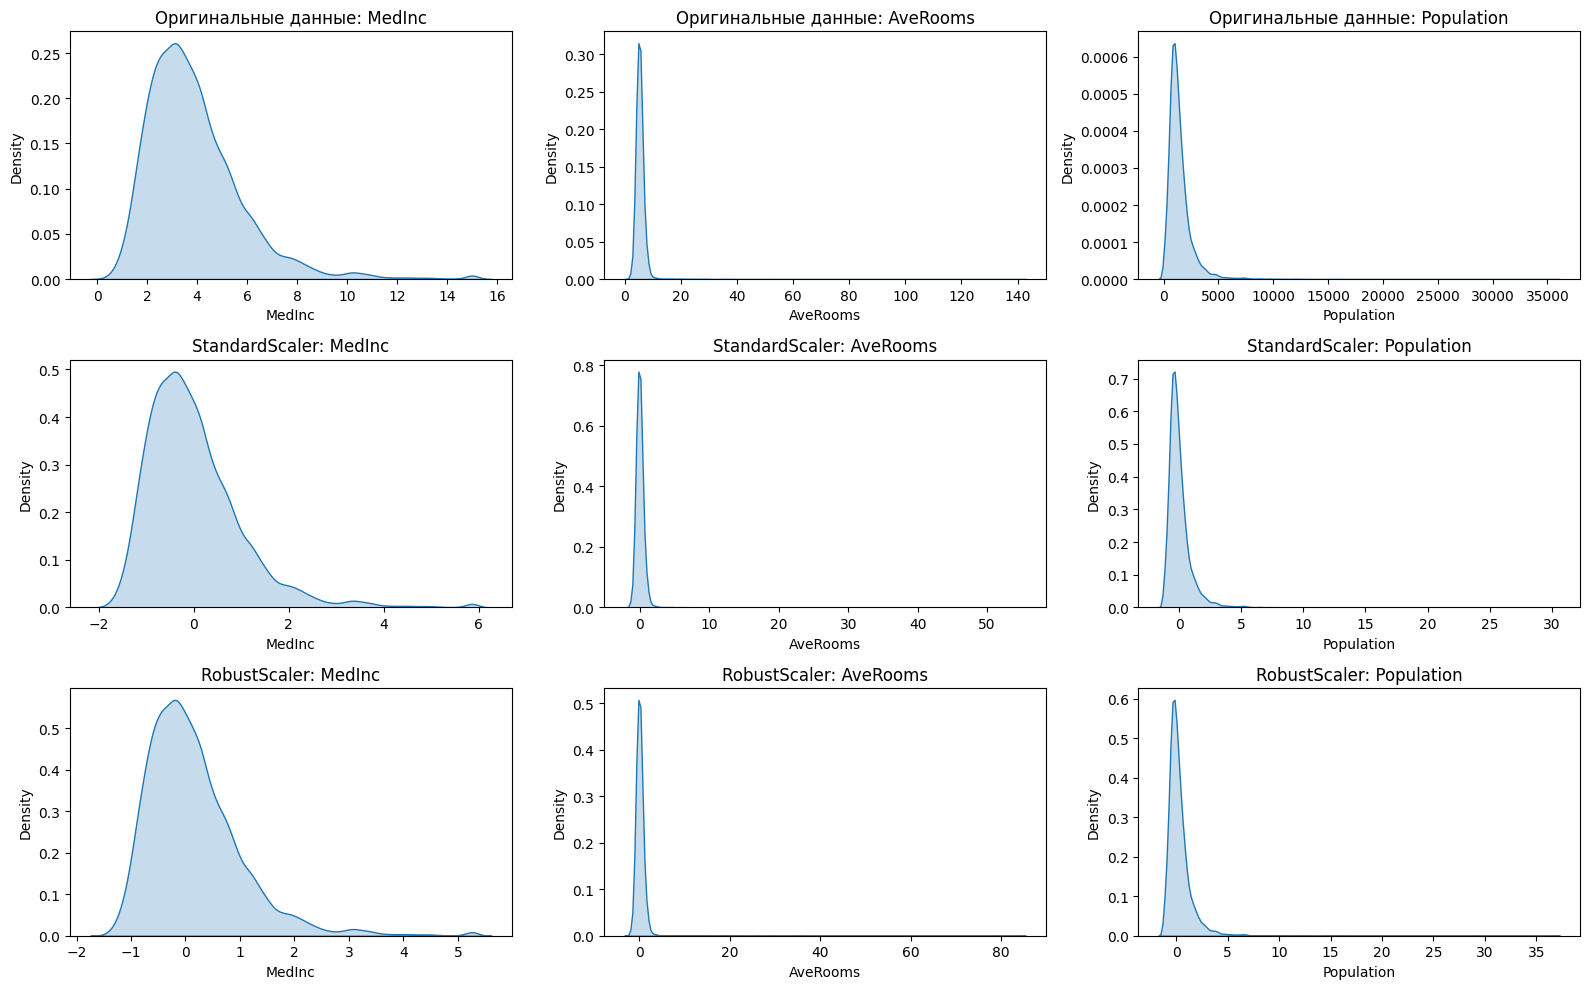

In [6]:
# ================================
# ЗАДАНИЕ 3 — МАСШТАБИРОВАНИЕ ДАННЫХ
# ================================

import pandas as pd              # Manipulation des données
import seaborn as sns            # Visualisation (KDE, histogrammes)
import matplotlib.pyplot as plt  # Graphiques
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. Выбор признаков
features = ['MedInc', 'AveRooms', 'Population']  # Trois variables numériques
data = df[features]                               # Extraction des colonnes du DataFrame

# 2. Создание масштабировщиков
scaler_standard = StandardScaler()   # Standardisation (moyenne = 0, écart-type = 1)
scaler_minmax = MinMaxScaler()       # Mise à l’échelle entre 0 et 1
scaler_robust = RobustScaler()       # Résistant aux outliers (utilise médiane et IQR)

# 3. Применение масштабирования
data_standard = scaler_standard.fit_transform(data)  # Applique StandardScaler
data_minmax = scaler_minmax.fit_transform(data)      # Applique MinMaxScaler
data_robust = scaler_robust.fit_transform(data)      # Applique RobustScaler

# 4. Преобразование в DataFrame для удобства
df_standard = pd.DataFrame(data_standard, columns=features)
df_minmax = pd.DataFrame(data_minmax, columns=features)
df_robust = pd.DataFrame(data_robust, columns=features)

# 5. Визуализация результатов
plt.figure(figsize=(16, 10))  # Taille de la figure

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.kdeplot(df[col], label='Original', fill=True)
    plt.title(f"Оригинальные данные: {col}")

    plt.subplot(3, 3, i + 4)
    sns.kdeplot(df_standard[col], label='StandardScaler', fill=True)
    plt.title(f"StandardScaler: {col}")

    plt.subplot(3, 3, i + 7)
    sns.kdeplot(df_robust[col], label='RobustScaler', fill=True)
    plt.title(f"RobustScaler: {col}")

plt.tight_layout()
plt.show()


## Вывод (академический текст)
Масштабирование показало, что методы нормализации по‑разному влияют на распределение признаков. StandardScaler хорошо работает для данных, близких к нормальному распределению, однако чувствителен к выбросам, что приводит к растяжению шкалы. MinMaxScaler приводит все значения к диапазону [0, 1], но также сильно зависит от экстремальных значений, поэтому при наличии выбросов диапазон сжимается. RobustScaler показал наилучшие результаты для признаков с выбросами, поскольку использует медиану и межквартильный размах, что делает его устойчивым к аномальным значениям. Таким образом, для данного набора данных, содержащего выбросы, наиболее подходящим методом является RobustScaler.
